In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
import copy
import random

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [3]:
DATA_DIR = r'/home/pcdm/Desktop/seg/seg_train'
model_algo="alexnet"

In [4]:

transform=transforms.Compose([
    transforms.Resize((229,229)),    
    transforms.ToTensor() 
])

In [5]:
#讀取資料且切分資料為train、valid、test

images=ImageDataset(DATA_DIR,transform,decision_mode=False)

generator = torch.Generator()
generator.manual_seed(124)

size = len(images)
valid_size = int(0.2 * size)
test_size = int(0.1 * size)
train_size = int(size - valid_size - test_size)

trainset, validset, testset = random_split(images, (train_size, valid_size, test_size), generator=generator)


In [6]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.23119273847004151,train_accu=0.9217610062893081
Epoch=0,valid_loss=0.2867520266309319,valid_accu=0.8987081620669407
0
Epoch=1,train_loss=0.13613212661798146,train_accu=0.9526205450733752
Epoch=1,valid_loss=0.23808307739229534,valid_accu=0.9128009395184967
0
Epoch=2,train_loss=0.08426040170827502,train_accu=0.9752620545073375
Epoch=2,valid_loss=0.22950073734420193,valid_accu=0.9210217263652378
0
Epoch=3,train_loss=0.05881800861986241,train_accu=0.9819706498951782
Epoch=3,valid_loss=0.23950515463467004,valid_accu=0.9198473282442748
Epoch=4,train_loss=0.08079838485212947,train_accu=0.9719916142557652
Epoch=4,valid_loss=0.28818825090274486,valid_accu=0.9057545507927187
Epoch=5,train_loss=0.024531677050410577,train_accu=0.9922851153039832
Epoch=5,valid_loss=0.29776959772442135,valid_accu=0.9192601291837933
Epoch=6,train_loss=0.028076821153581268,train_accu=0.9906079664570231
Epoch=6,valid_loss=0.32538214048094,valid_accu=0.916030534351145
4 Early stopping!


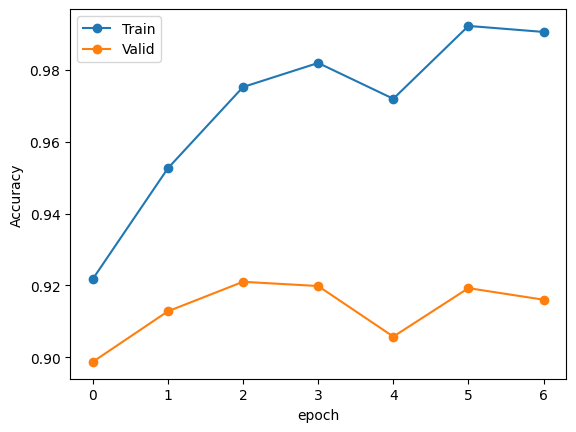

In [7]:
model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
# model_0 = torch.load(f'model_{model_algo}_0_6.pth')

In [8]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.08426040198318113, 0.9752620545073375)

In [9]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.22950073484281058, 0.9210217263652378)

In [10]:
each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
each_accu

buildings    0.985350
forest       0.994802
glacier      0.949244
mountain     0.963117
sea          0.978778
street       0.983566
dtype: float64

In [11]:
targetF=[x  for x in each_accu.nsmallest(2).index.map(trainset.dataset.classess)]
targetF

[2, 3]

In [12]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('classaccu',targetF)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
len(indexF),len(indexT)

(4218, 7707)

In [13]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(1169, 2237)

In [14]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)
Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

In [15]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [16]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.06386493494007854,train_accu=0.979874213836478
Epoch=0,valid_loss=0.08188895288148279,valid_accu=0.9747504403992954
0
Epoch=1,train_loss=0.04102376366625745,train_accu=0.9851572327044025
Epoch=1,valid_loss=0.07559659337177567,valid_accu=0.9759248385202584
0
Epoch=2,train_loss=0.023949070973907534,train_accu=0.9911111111111112
Epoch=2,valid_loss=0.09020765955745572,valid_accu=0.9732824427480916
Epoch=3,train_loss=0.027203309525788394,train_accu=0.989601677148847
Epoch=3,valid_loss=0.08378893160356916,valid_accu=0.9726952436876101
Epoch=4,train_loss=0.028378577656981454,train_accu=0.9894339622641509
Epoch=4,valid_loss=0.1017499998547093,valid_accu=0.9682912507339988
Epoch=5,train_loss=0.00622214963957394,train_accu=0.9982389937106918
Epoch=5,valid_loss=0.07579644816016796,valid_accu=0.9768056371109807
0
Epoch=6,train_loss=0.01805284710169662,train_accu=0.9937106918238994
Epoch=6,valid_loss=0.11641869311785863,valid_accu=0.9750440399295361
Epoch=7,train_loss=0.0077428

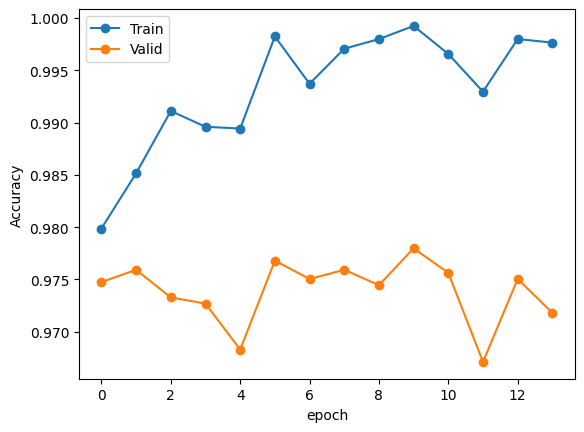

In [17]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32)
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70,trainclassnum=len(trainset.dataset.classes))

Epoch=0,train_loss=0.07865428638602101,train_accu=0.973011547943428
Epoch=0,valid_loss=0.11402946117737488,valid_accu=0.959767545820295
0
Epoch=1,train_loss=0.0451003726524912,train_accu=0.9859867652783184
Epoch=1,valid_loss=0.09967252853500108,valid_accu=0.9637907912382655
0
Epoch=2,train_loss=0.05023393536087324,train_accu=0.9831322174646425
Epoch=2,valid_loss=0.1508353002299461,valid_accu=0.9490388913723737
Epoch=3,train_loss=0.031313137888794314,train_accu=0.9887115609186454
Epoch=3,valid_loss=0.14114692588043257,valid_accu=0.9530621367903442
Epoch=4,train_loss=0.02282176260255539,train_accu=0.9911768522122746
Epoch=4,valid_loss=0.1571000578957304,valid_accu=0.9526151095216808
Epoch=5,train_loss=0.007150433382305008,train_accu=0.9980537173997664
Epoch=5,valid_loss=0.1951829680426077,valid_accu=0.957532409476978
4 Early stopping!


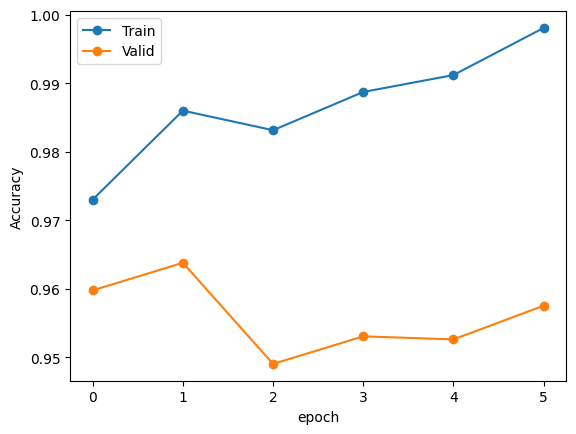

In [18]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=0.23643860904850514,train_accu=0.9160739687055477
Epoch=0,valid_loss=0.3006267653406941,valid_accu=0.8768177929854577
0
Epoch=1,train_loss=0.19500552304354027,train_accu=0.9253200568990043
Epoch=1,valid_loss=0.29847468885730943,valid_accu=0.8776732249786142
0
Epoch=2,train_loss=0.10501886688035039,train_accu=0.9656235182550972
Epoch=2,valid_loss=0.2832436188864239,valid_accu=0.8939264328485885
0
Epoch=3,train_loss=0.152909694678442,train_accu=0.9378852536747273
Epoch=3,valid_loss=0.35101682518770594,valid_accu=0.8622754491017964
Epoch=4,train_loss=0.08902282870850217,train_accu=0.9632527264106211
Epoch=4,valid_loss=0.3710944751983427,valid_accu=0.8870829769033362
Epoch=5,train_loss=0.04579388006511261,train_accu=0.9912280701754386
Epoch=5,valid_loss=0.31125720593539746,valid_accu=0.8973481608212147
0
Epoch=6,train_loss=0.017262613376639625,train_accu=0.9954954954954955
Epoch=6,valid_loss=0.3716295773467771,valid_accu=0.9016253207869974
0
Epoch=7,train_loss=0.01494888

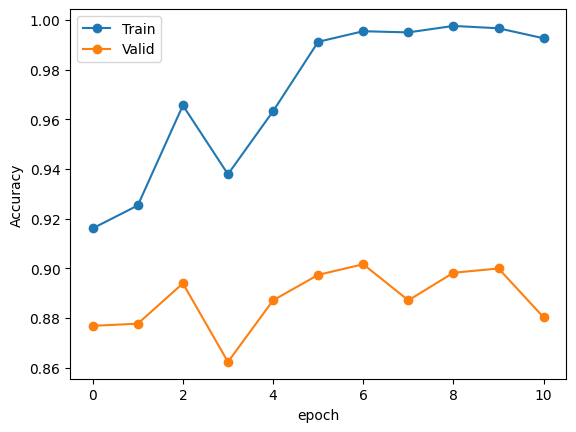

In [19]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [20]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.0024900862467777864, 0.999245283018868)

In [21]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.09768722518986189, 0.9779800352319437)

In [22]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.04510037313295552, 0.9859867652783184)

In [23]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.017262613665552755, 0.9954954954954955)

In [24]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.09967252739593153, 0.9637907912382655)

In [25]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(0.3716292995178771, 0.9016253207869974)

In [26]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(0.03525377247958938, 0.989350104821803, 4218)

In [27]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.19301355784595958, 0.9424544920728127, 1169)

In [28]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.046122159300610206, 0.9886792452830189, 4221, 7704)

In [29]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(0.5209442035711238, 0.9236641221374046, 1168, 2238)

In [30]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [31]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.084260,0.975262,0.229501,0.921022
1,Model_Decision,0.002490,0.999245,0.002490,0.977980
2,Model_T,0.045100,0.985987,0.099673,0.963791
3,Model_F,0.017263,0.995495,0.371629,0.901625
4,Total_Model,0.046122,0.988679,0.520944,0.923664
5,Total_Model_without_decision,0.035254,0.989350,0.193014,0.942454


In [48]:
def plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,model_name,model_algo):
    fig = plt.figure(figsize=(45, 15))
    ax1, ax2 = fig.add_subplot(121), fig.add_subplot(122)
    sns.heatmap(confusion_matrix_train, annot=True, fmt='g',cbar=False,ax=ax1,square=True).set(title=f"{model_algo}_{model_name} train confusion matrix", xlabel="Predicted Label", ylabel="True Label")
    sns.heatmap(confusion_matrix_valid, annot=True, fmt='g',ax=ax2,square=True).set(title=f"{model_algo}_{model_name} valid confusion matrix", xlabel="Predicted Label", ylabel="True Label")


,0,1
0,4215,3
1,6,7701


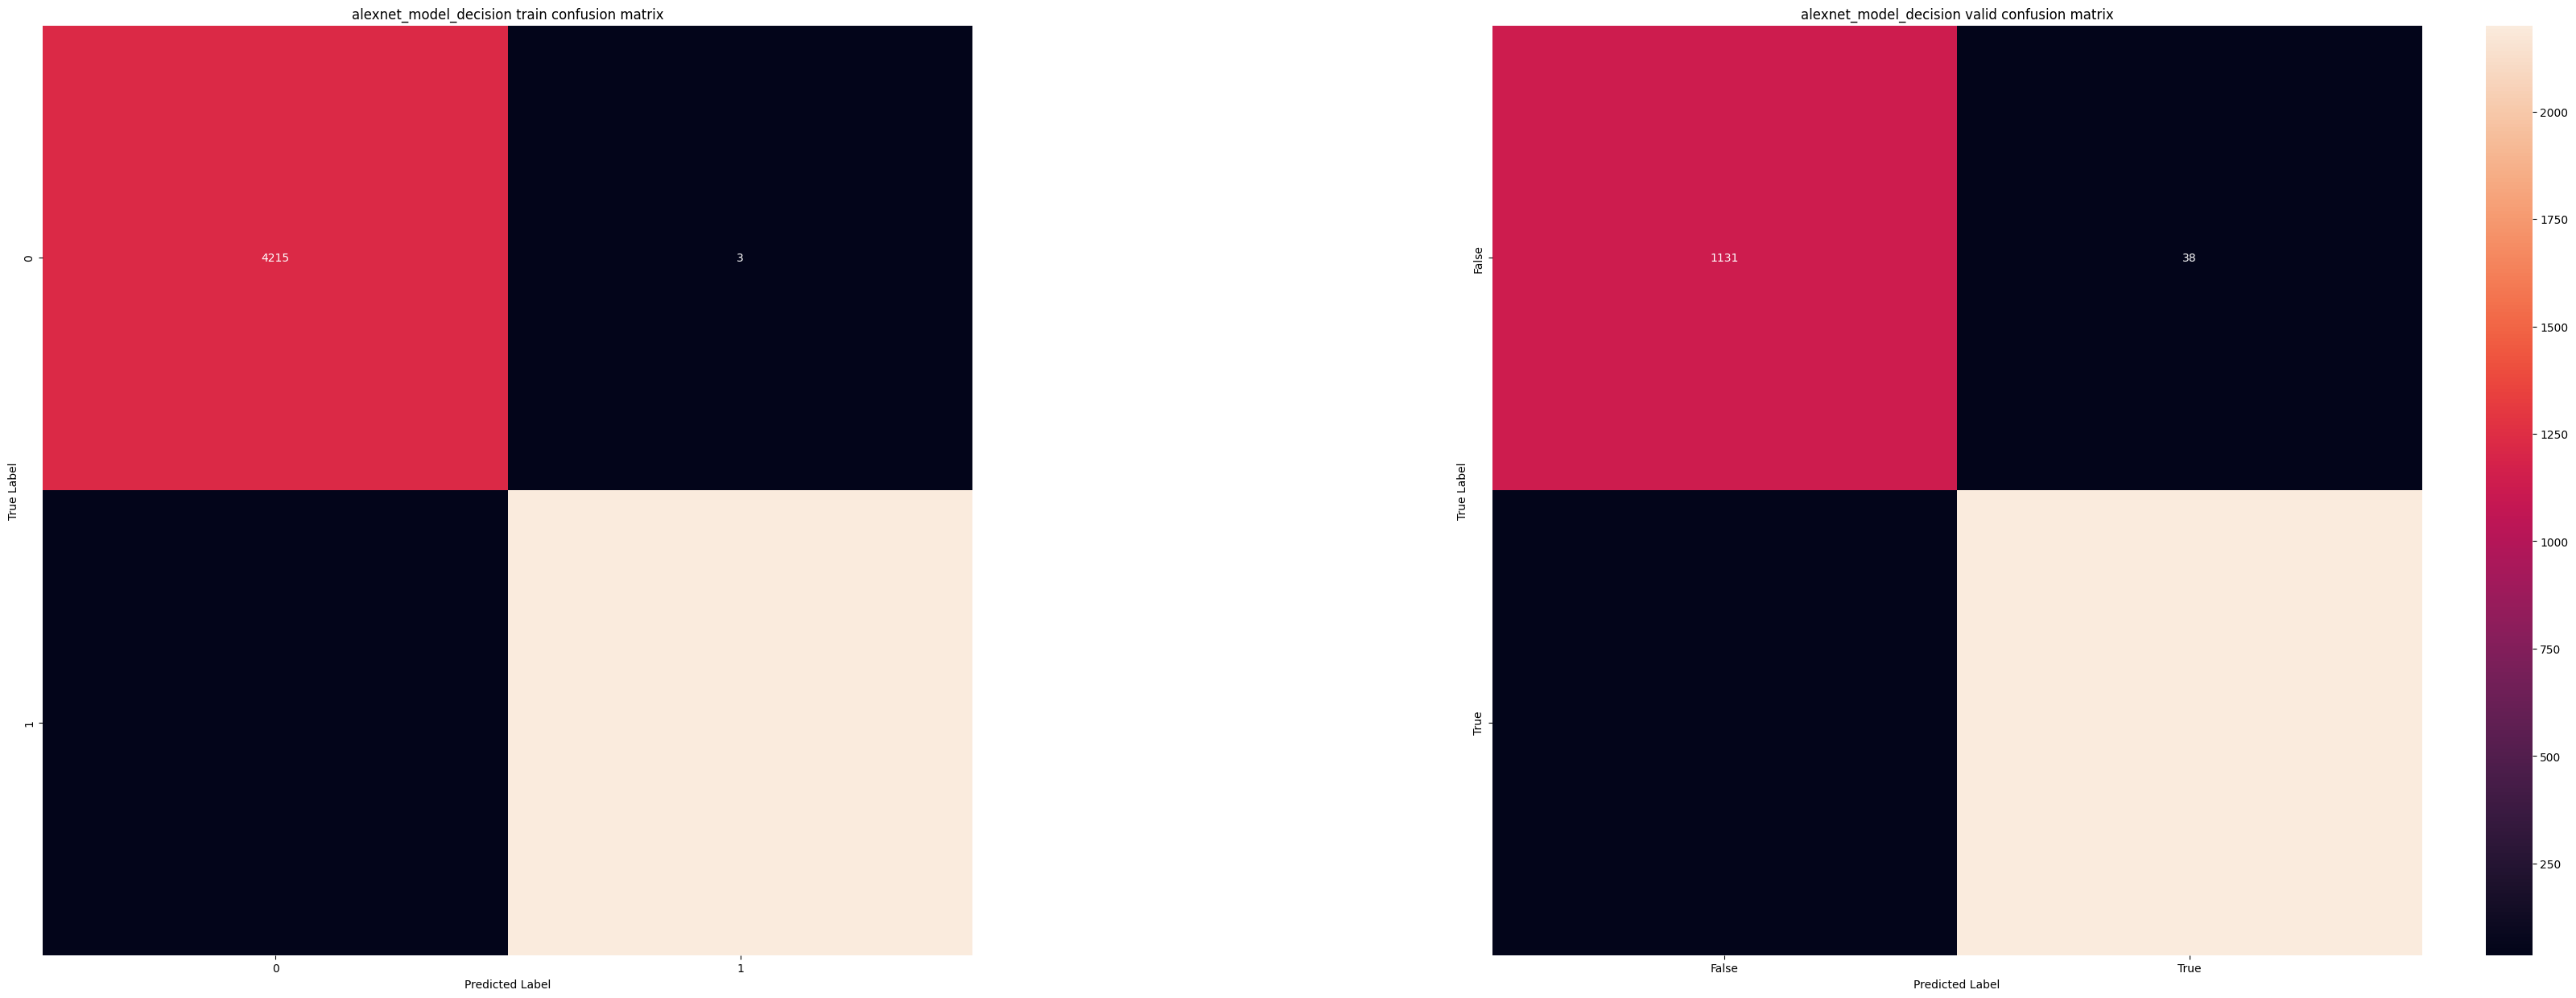

In [49]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)
confusion_matrix_decision_train

,buildings,forest,glacier,mountain,sea,street
buildings,1816,0,1,1,0,25
forest,0,1914,4,6,0,0
glacier,3,3,1945,84,12,2
mountain,0,0,75,2089,5,0
sea,2,0,28,10,1891,1
street,32,0,0,1,0,1975


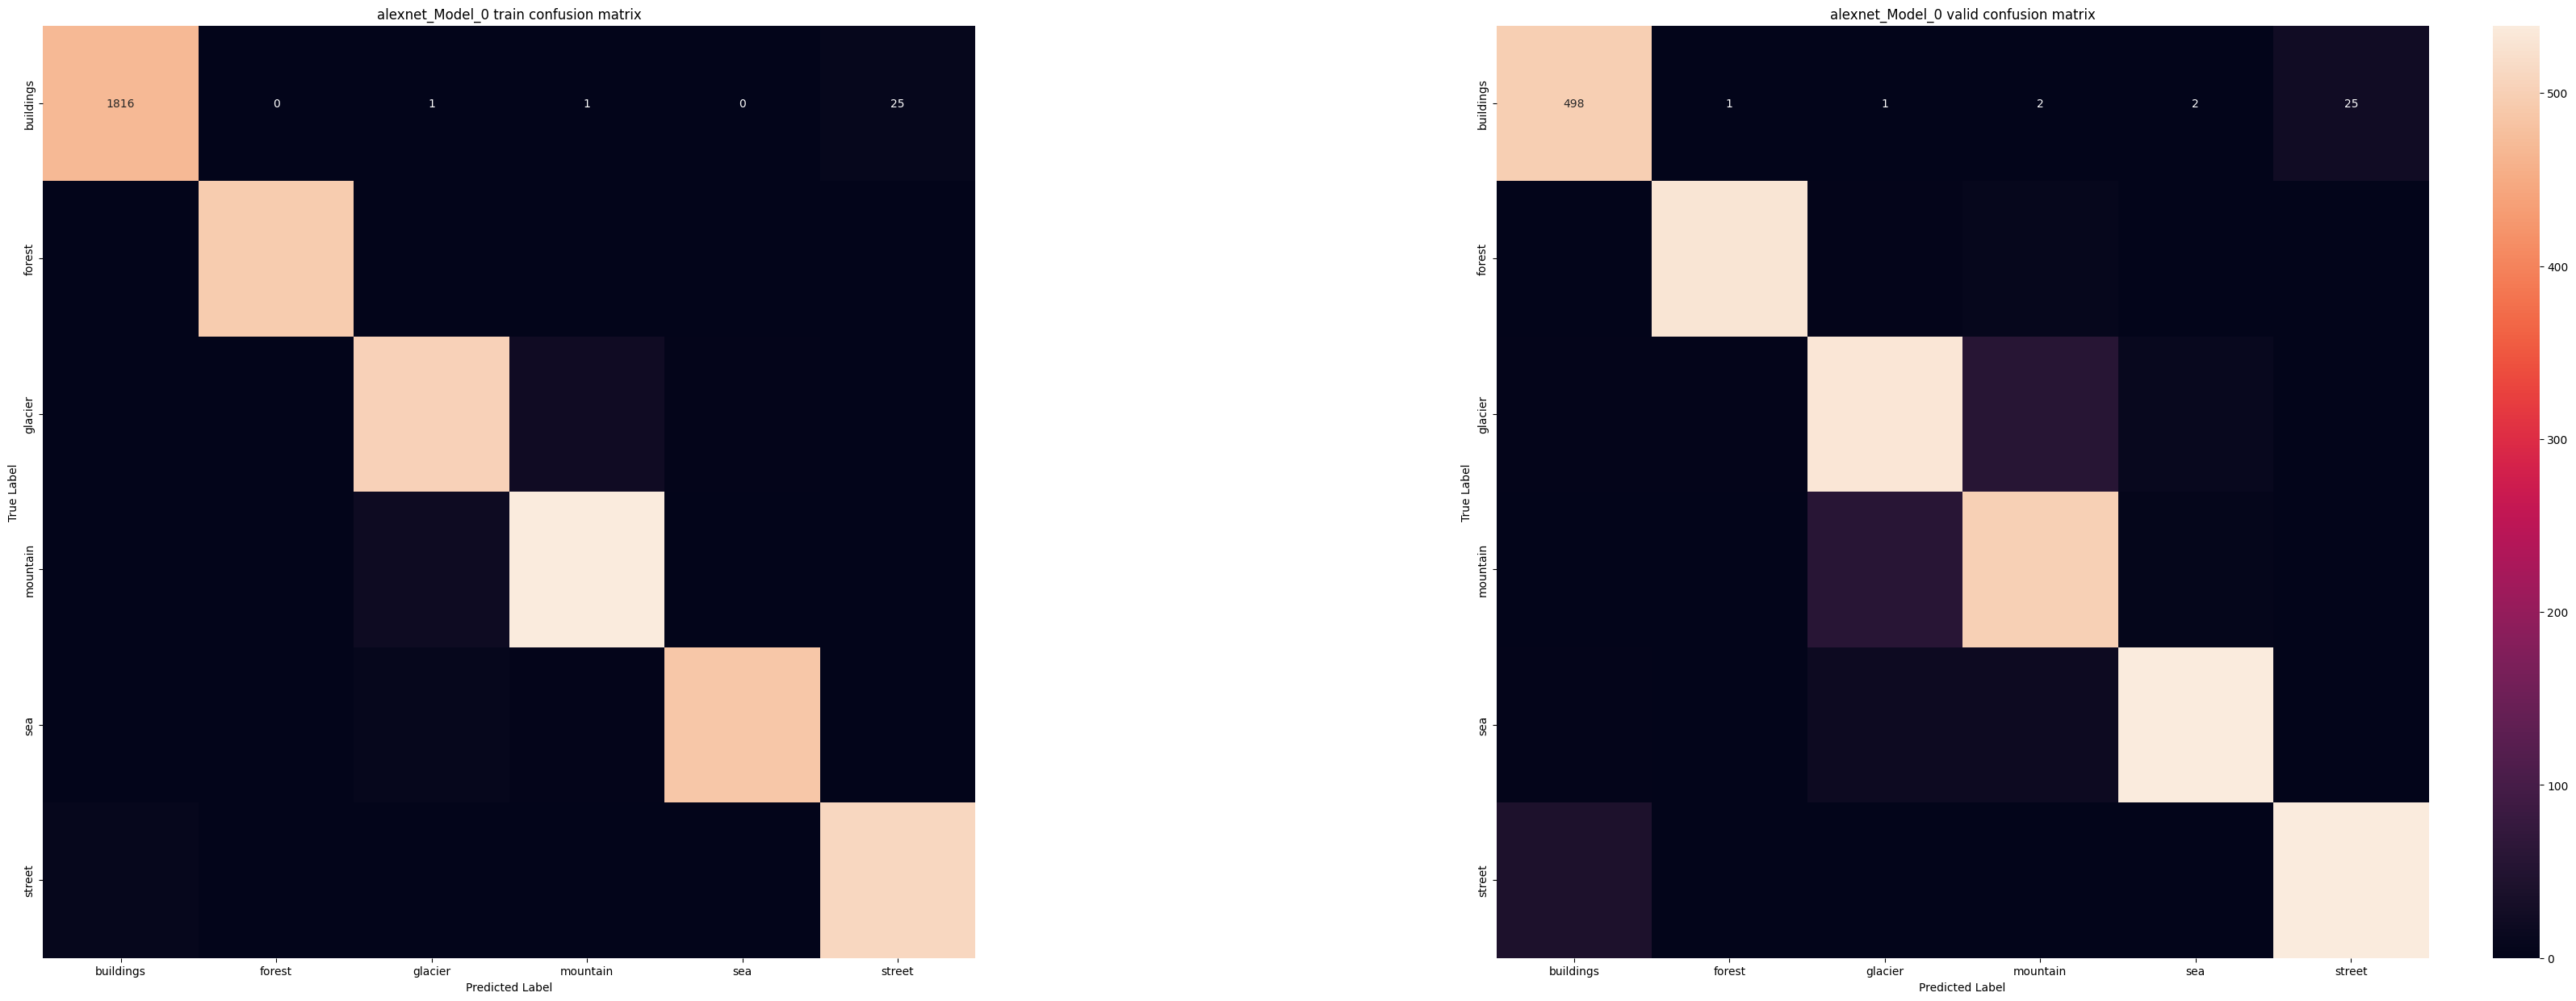

In [50]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)
confusion_matrix_train

,buildings,forest,glacier,mountain,sea,street
buildings,1784,0,0,0,1,58
forest,0,1917,0,1,6,0
glacier,0,1,2033,15,0,0
mountain,1,0,4,2163,1,0
sea,6,0,1,4,1918,3
street,25,7,0,0,1,1975


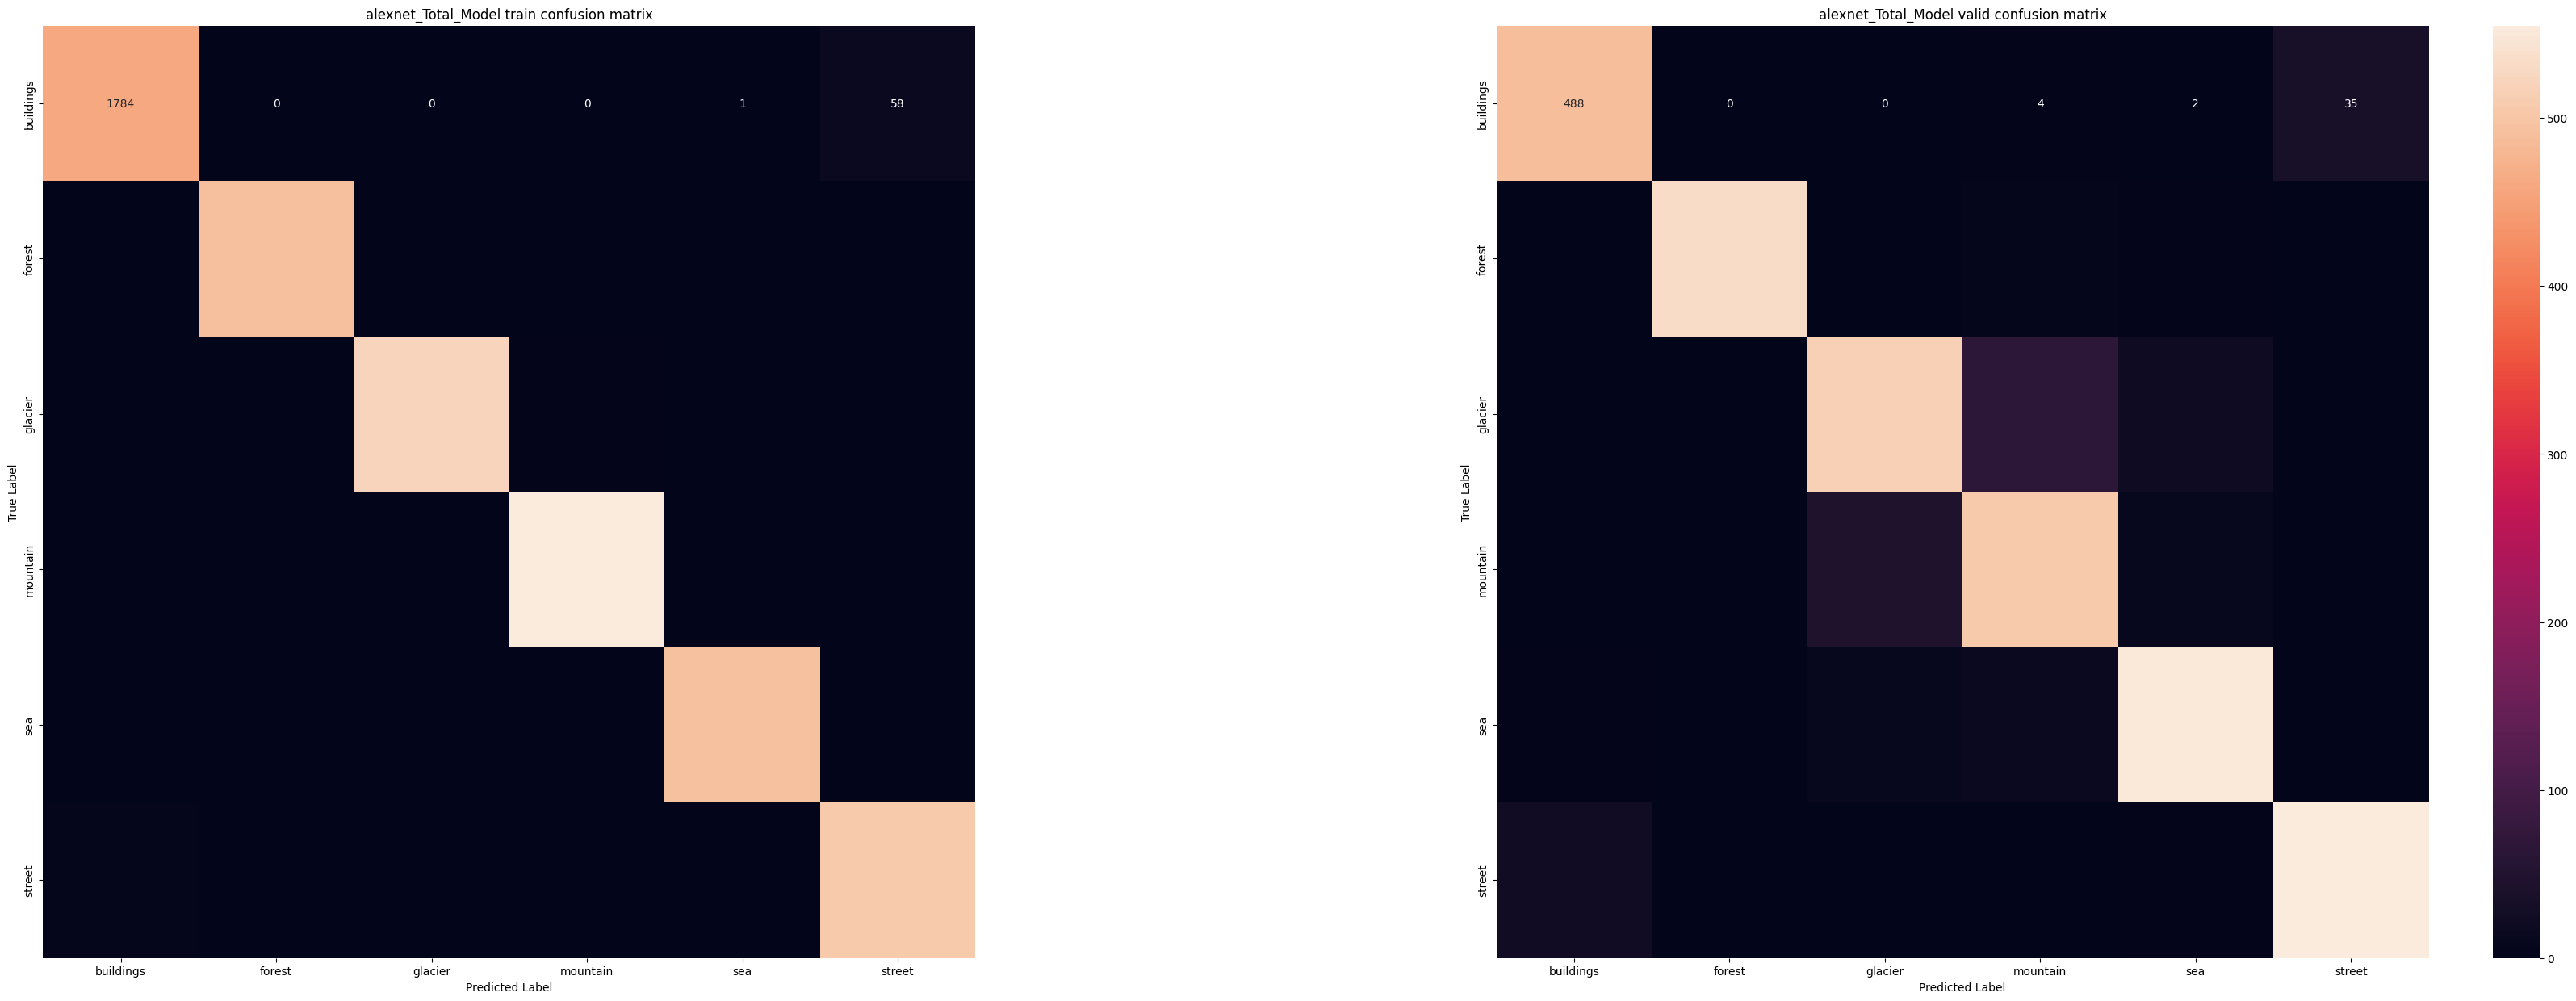

In [51]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)
confusion_matrix_total_train

,buildings,forest,sea,street
buildings,1784,0,1,58
forest,0,1917,7,0
sea,6,0,1923,3
street,25,7,1,1975


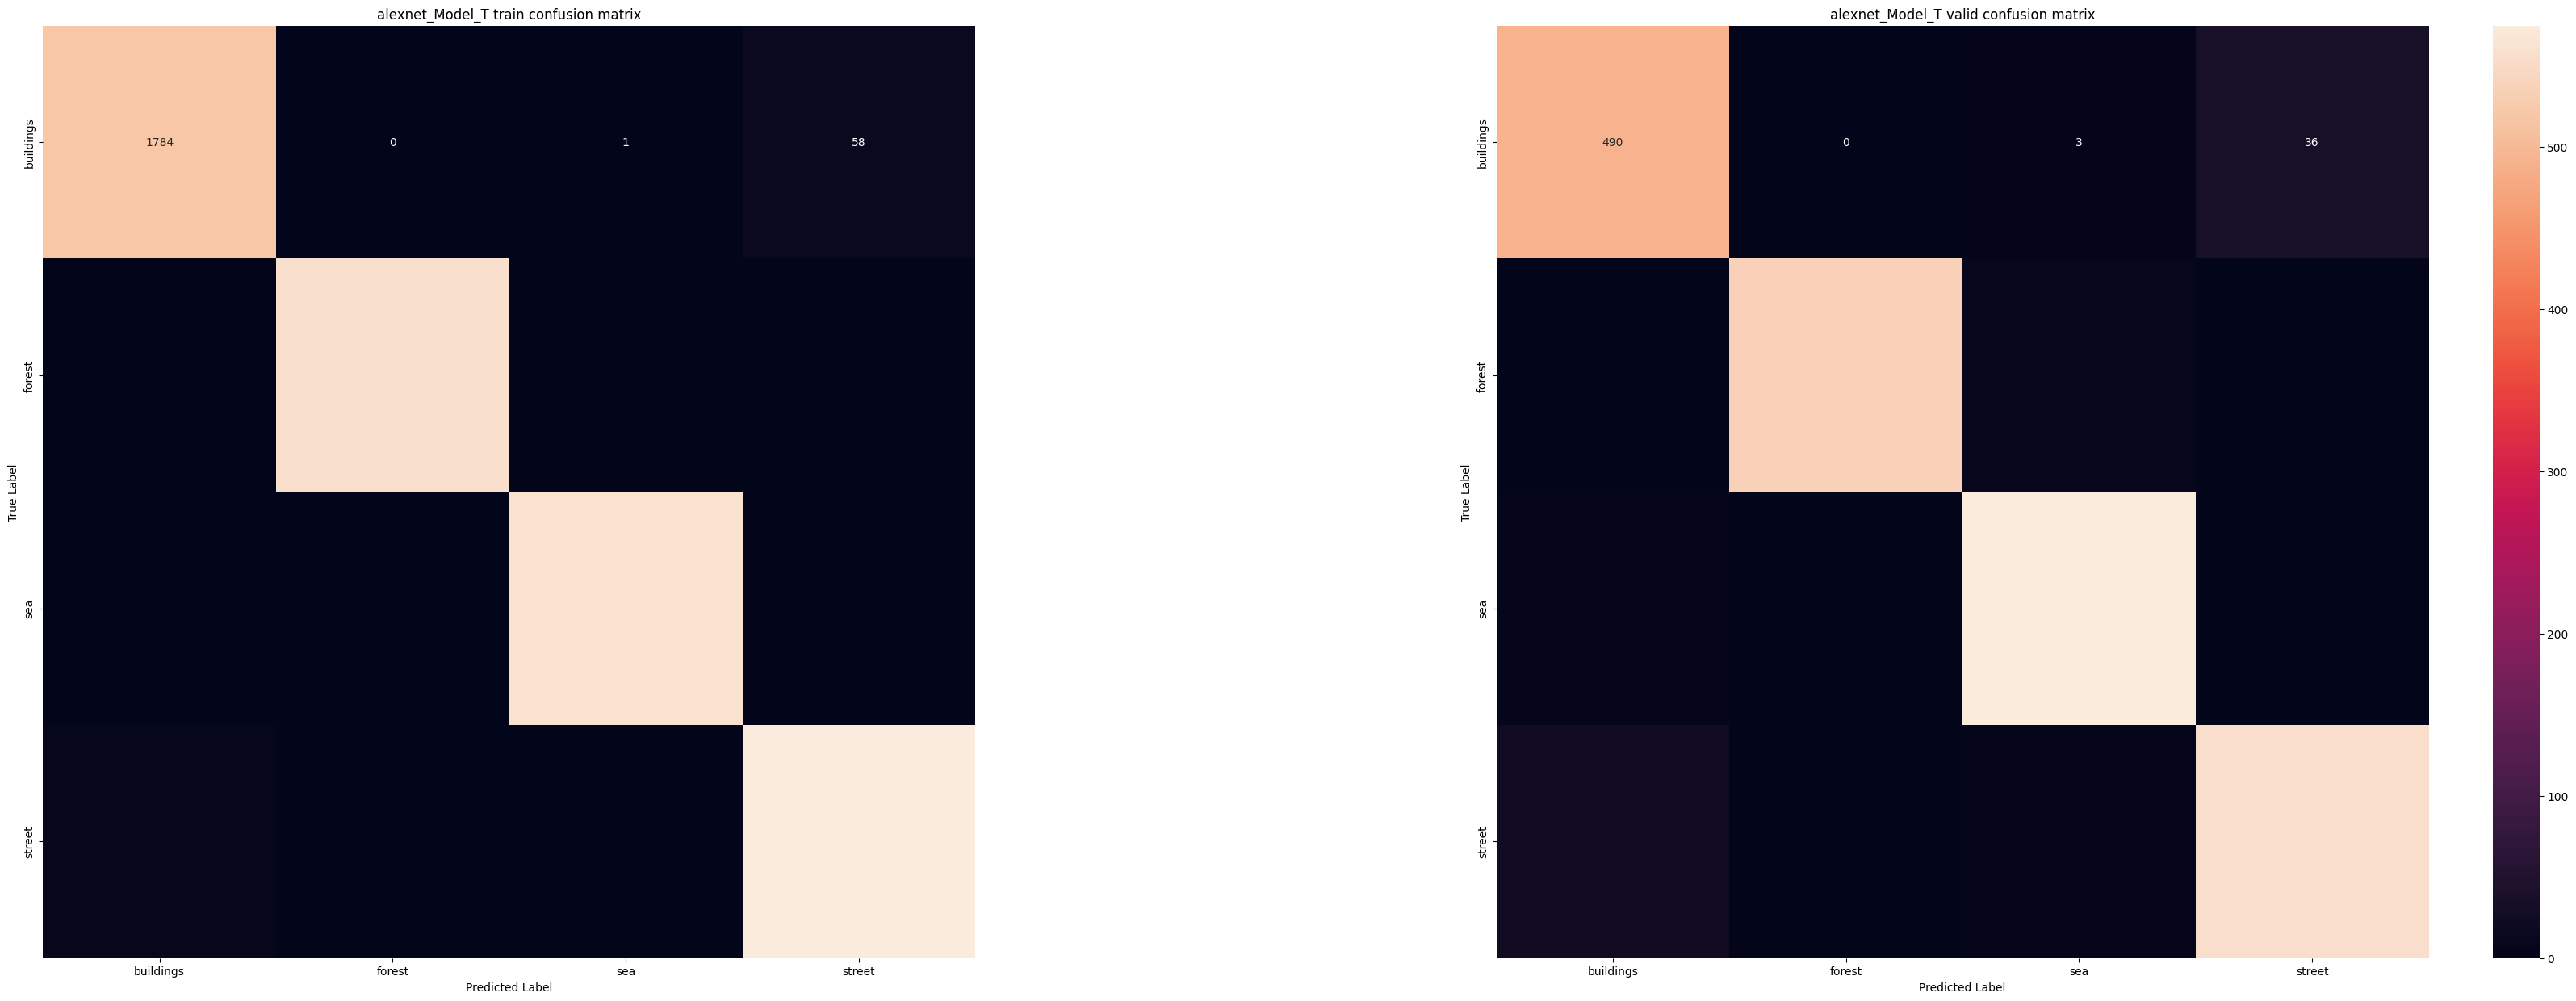

In [52]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)
confusion_matrix_T_train

,glacier,mountain
glacier,2034,15
mountain,4,2165


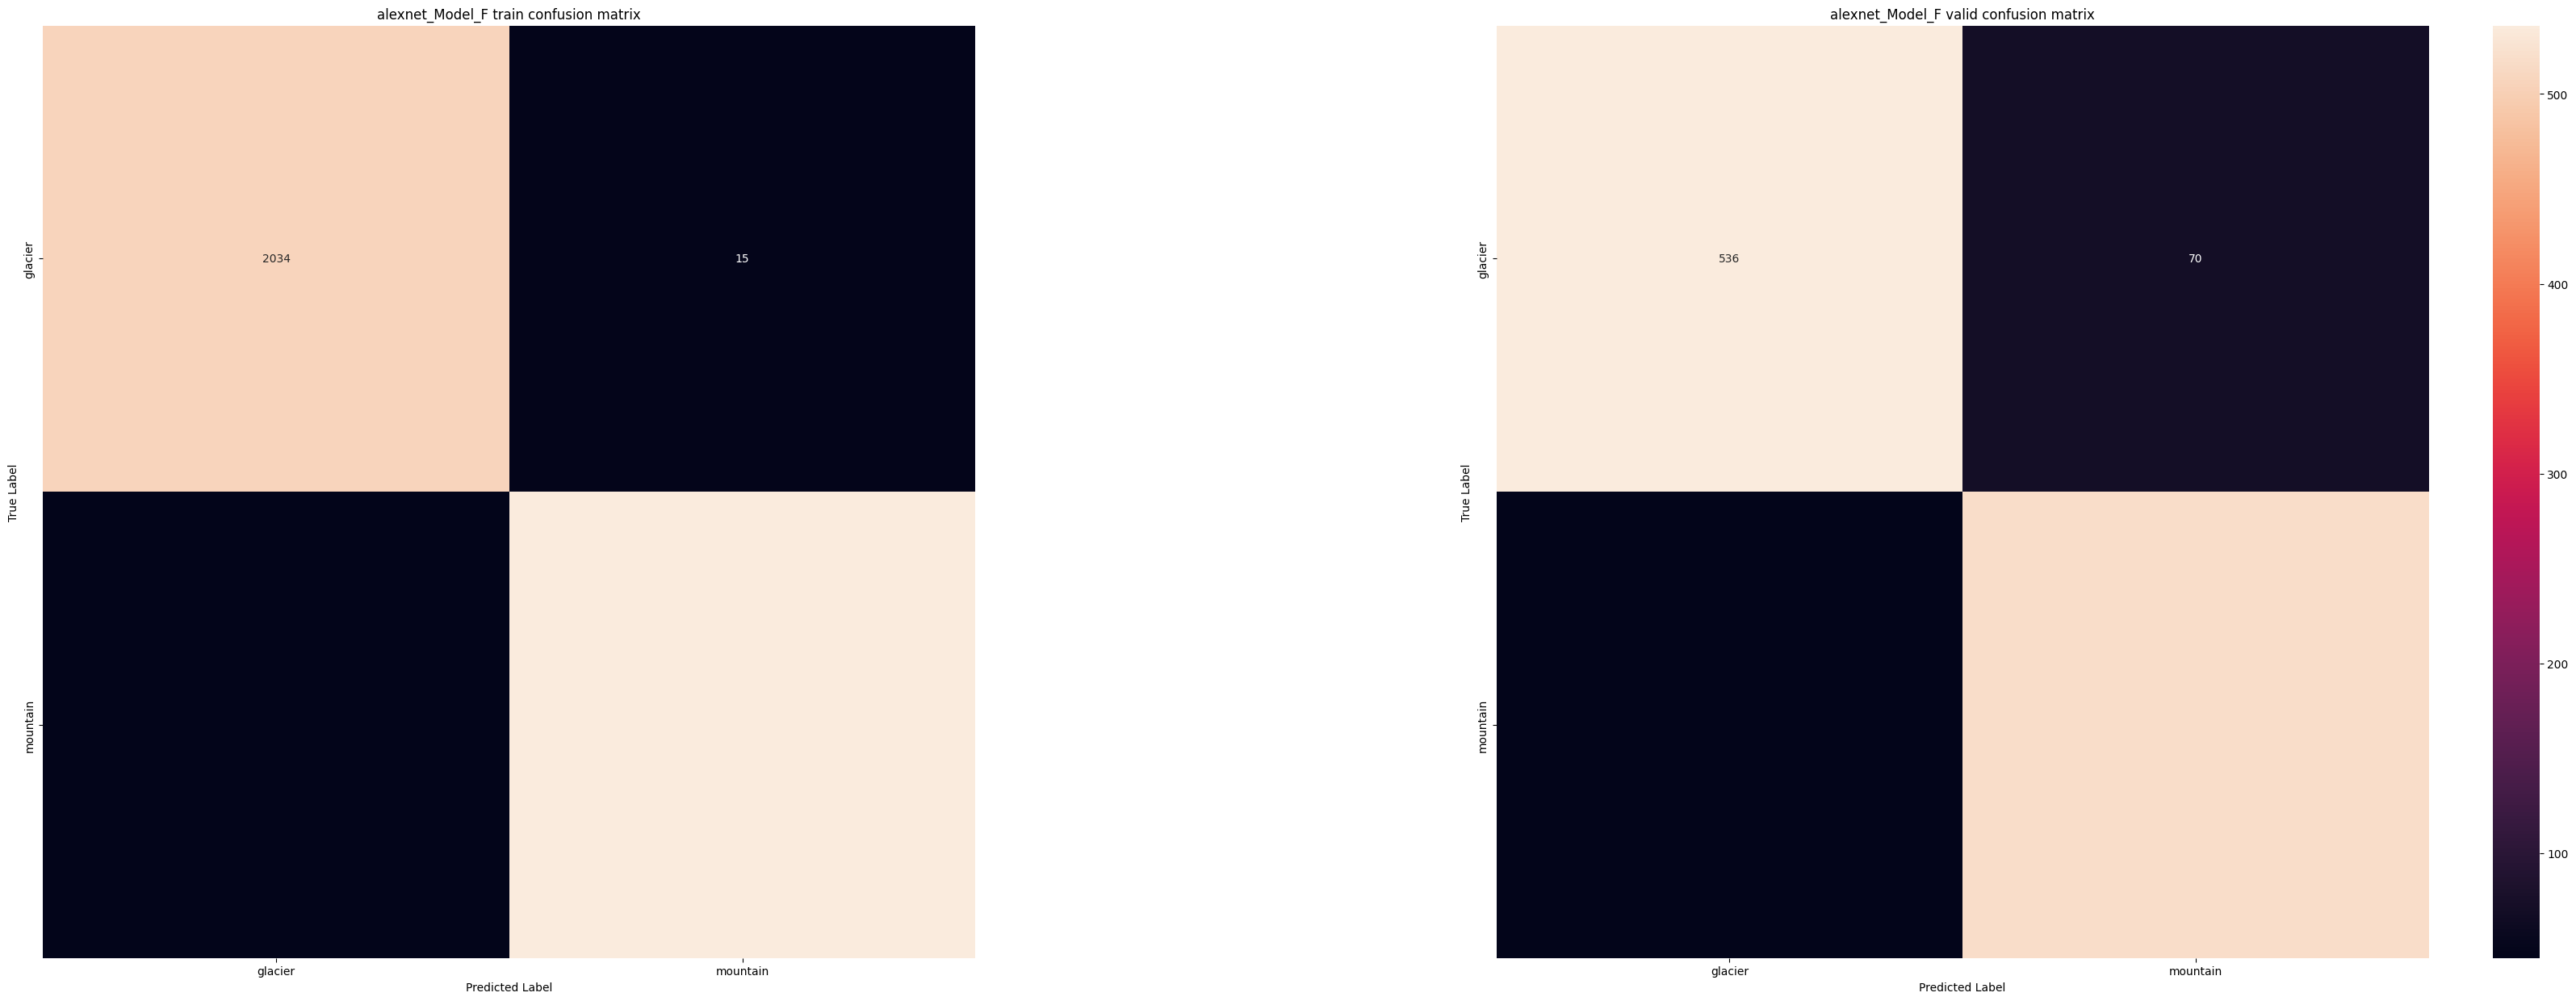

In [53]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)
confusion_matrix_F_train